# TransOrg AgentIQ Datathon

# Track 3: AgriTech — Mandi-to-Market Supply Chain Optimizer

### Datasets
1. Mandi Arrivals — crop arrivals with mixed names, units and dates.
2. Price & MSP — wholesale prices and MSP.
3. Weather Sensors — temperature, rainfall and mixed timestamps/units.
4. Transport Logistics — trips, distances, vehicles and transit times.
5. Mandi Master — mandi and district master data.

### Join Keys
- Arrivals ↔ Mandi Master: `mandi_id`
- Prices ↔ Mandi Master: `mandi_id`
- Transport ↔ Mandi Master: `mandi_id`
- Weather: aggregate by date because no direct sensor-to-mandi key is available.

### Business Metrics
- Total arrivals
- Modal price vs MSP
- Price-crash instances
- Average transit time
- Long transit rate
- Weather vs arrival volume
- Top mandis
- Crop-wise arrivals

## 1. Import Libraries

In [89]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Datasets

In [90]:
arrivals_path = '/content/track3_mandi_arrivals.csv'
price_path = '/content/track3_price_and_msp.json'
weather_path = '/content/track3_weather_sensors.xlsx'
transport_path = '/content/track3_transport_logistics.csv'
mandi_master_path = '/content/track3_mandi_master.csv'

arrivals_df = pd.read_csv(arrivals_path)
price_msp_df = pd.read_json(price_path)
weather_sensors_df = pd.read_excel(weather_path)
transport_logistics_df = pd.read_csv(transport_path)
mandi_master_df = pd.read_csv(mandi_master_path)

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 3. Dataset Overview

In [91]:
datasets = {
    'Mandi Arrivals': arrivals_df,
    'Price & MSP': price_msp_df,
    'Weather Sensors': weather_sensors_df,
    'Transport Logistics': transport_logistics_df,
    'Mandi Master': mandi_master_df
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nDescriptive Statistics:")
    display(df.describe(include='all').transpose())
    print()

Mandi Arrivals
Shape: (25750, 8)
Columns: ['arrival_id', 'date', 'mandi_id', 'crop_name', 'variety', 'arrival_quantity', 'unit', 'farmer_count']

Data Types:
arrival_id           object
date                 object
mandi_id             object
crop_name            object
variety              object
arrival_quantity     object
unit                 object
farmer_count        float64
dtype: object

First 5 rows:


,arrival_id,date,mandi_id,crop_name,variety,arrival_quantity,unit,farmer_count
0,ARR0012424,06-04-2026,MANDI026,गेहूं,Hybrid,44.841,T,128.0
1,ARR0008271,2026-06-02,MANDI014,Gehun,HD-2967,332.54,Qtl,33.0
2,ARR0022724,08-16-2026,056,Kanak,HD-2967,415.88 qtl,NaN,NaN
3,ARR0012573,06-24-2026,MANDI019,Maize,NaN,-107.13,KG,112.0
4,ARR0012098,09.08.2026,mandi050,Corn,Premium,-331.59,Qtl,NaN



Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
arrival_id,25266,24524,ARR0008023,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,25750,1512,07/04/2026,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mandi_id,25750,342,MANDI002,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop_name,25750,36,Sugarcane,918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variety,22015,6,Local,3721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_quantity,25750,23609,154.41,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit,20607,14,Qtl,2114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
farmer_count,21851.0,NaN,NaN,NaN,77.616265,42.054199,5.0,41.0,78.0,114.0,150.0



Price & MSP
Shape: (12000, 9)
Columns: ['record_id', 'date', 'mandi_id', 'district', 'crop_name', 'min_price', 'max_price', 'modal_price', 'msp']

Data Types:
record_id              object
date           datetime64[ns]
mandi_id               object
district               object
crop_name              object
min_price              object
max_price              object
modal_price            object
msp                    object
dtype: object

First 5 rows:


...

,count,unique,top,freq
trip_id,10400,10000,TRP007602,2
mandi_id,10400,342,MANDI037,105
destination_warehouse,10400,6,WH-North,1782
departure_time,10400,9315,15/05/2026,10
arrival_time,9347,8353,04/05/2026,10
transit_hours,9882,617,12.9,63
distance,10400,7939,956.7,6
distance_unit,9368,2,km,7815
vehicle_no,8778,8438,UP-21-DF-7459,2
driver_id,8849,899,DRV915,25



Mandi Master
Shape: (60, 6)
Columns: ['mandi_id', 'mandi_name', 'district', 'state', 'mandi_type', 'total_area_acres']

Data Types:
mandi_id             object
mandi_name           object
district             object
state                object
mandi_type           object
total_area_acres    float64
dtype: object

First 5 rows:


,mandi_id,mandi_name,district,state,mandi_type,total_area_acres
0,MANDI001,Hyderabad Mandi,ludhiana,Punjab,Private,11.0
1,MANDI006,Kochi Mandi,Amritsar,Punjab,Direct,34.0
2,MANDI037,Jorhat Grain Market,Kurukshetra,Haryana,APMC,NaN
3,MANDI046,Baranagar Market,NaN,Uttar Pradesh,Private,13.0
4,MANDI014,Bathinda Grain Market,Patiala,Punjab,PRIVATE,25.0



Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mandi_id,60,57,MANDI001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mandi_name,60,57,Hyderabad Mandi,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,56,27,Amritsar,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,56,3,Punjab,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mandi_type,49,5,APMC,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_area_acres,54.0,NaN,NaN,NaN,27.611111,12.765544,5.0,17.5,27.5,38.75,48.0


## 4. Initial Data Quality Check

In [92]:
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Duplicate Rows': df.duplicated().sum(),
        'Missing Values': df.isna().sum().sum(),
        'Missing Value %': round((df.isna().sum().sum() / df.size) * 100, 2)
    })

quality_summary_df = pd.DataFrame(quality_summary)
display(quality_summary_df)

,Dataset,Rows,Columns,Duplicate Rows,Missing Values,Missing Value %
0,Mandi Arrivals,25750,8,750,13261,6.44
1,Price & MSP,12000,9,0,2008,1.86
2,Weather Sensors,15000,7,0,6900,6.57
3,Transport Logistics,10400,10,400,5776,5.55
4,Mandi Master,60,6,3,25,6.94


### Missing Values by Column

In [93]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)

    missing_df = pd.DataFrame({
        'Missing Count': df.isna().sum(),
        'Missing %': (df.isna().mean() * 100).round(2)
    })

    missing_df = missing_df[missing_df['Missing Count'] > 0]

    if missing_df.empty:
        print("No missing values found.")
    else:
        display(missing_df.sort_values('Missing Count', ascending=False))

Mandi Arrivals


,Missing Count,Missing %
unit,5143,19.97
farmer_count,3899,15.14
variety,3735,14.50
arrival_id,484,1.88


Price & MSP


,Missing Count,Missing %
mandi_id,1235,10.29
district,773,6.44


Weather Sensors


,Missing Count,Missing %
temp_unit,2263,15.09
timestamp,1555,10.37
humidity_percent,1500,10.00
rainfall,791,5.27
rain_unit,791,5.27


Transport Logistics


,Missing Count,Missing %
vehicle_no,1622,15.60
driver_id,1551,14.91
arrival_time,1053,10.12
distance_unit,1032,9.92
transit_hours,518,4.98


Mandi Master


,Missing Count,Missing %
mandi_type,11,18.33
total_area_acres,6,10.00
state,4,6.67
district,4,6.67


## 5. Cleaning Plan

Next, we will standardize:

- Mandi IDs
- Crop names
- Vehicle registration numbers
- Quantity → Quintals
- Distance → Kilometers
- Prices → Numeric
- UTC → IST
- Fahrenheit → Celsius
- Rainfall inches → Millimeters
- Transit times and timestamps

Then we will validate the cleaned data before integration, preprocessing, EDA, and feature engineering.

## 6. Check Columns Before Cleaning

In [94]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.columns.tolist())

Mandi Arrivals
['arrival_id', 'date', 'mandi_id', 'crop_name', 'variety', 'arrival_quantity', 'unit', 'farmer_count']
Price & MSP
['record_id', 'date', 'mandi_id', 'district', 'crop_name', 'min_price', 'max_price', 'modal_price', 'msp']
Weather Sensors
['sensor_id', 'timestamp', 'temperature', 'temp_unit', 'rainfall', 'rain_unit', 'humidity_percent']
Transport Logistics
['trip_id', 'mandi_id', 'destination_warehouse', 'departure_time', 'arrival_time', 'transit_hours', 'distance', 'distance_unit', 'vehicle_no', 'driver_id']
Mandi Master
['mandi_id', 'mandi_name', 'district', 'state', 'mandi_type', 'total_area_acres']


## 7. Standardize Mandi IDs and Crop Names

In [95]:
def standardize_mandi_id(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()
    value = re.sub(r'[-_\s]', '', value)

    if value.startswith('MANDI'):
        number = value.replace('MANDI', '', 1)
    elif value.startswith('M'):
        number = value[1:]
    else:
        number = value

    if number.isdigit():
        return f"MANDI{int(number):03d}"

    return value


for df in datasets.values():
    if 'mandi_id' in df.columns:
        df['mandi_id'] = df['mandi_id'].apply(standardize_mandi_id)

In [96]:
crop_name_mapping = {
    'gehun': 'Wheat',
    'गेहूं': 'Wheat',
    'kanak': 'Wheat',

    'maize': 'Maize',
    'corn': 'Maize',
    'mक्का': 'Maize',

    'paddy': 'Rice',
    'rice': 'Rice',
    'dhaan': 'Rice',
    'धान': 'Rice',

    'sugarcane': 'Sugarcane',
    'ganna': 'Sugarcane',
    'ganne': 'Sugarcane',
    'गन्ना': 'Sugarcane',

    'cotton': 'Cotton',
    'kapas': 'Cotton',
    'cotton (kapas)': 'Cotton',
    'narma': 'Cotton',
    'कपास': 'Cotton',

    'mustard': 'Mustard',
    'sarson': 'Mustard',
    'सरसों': 'Mustard',

    'bajra': 'Millet',
    'बाजरा': 'Millet',

    'soyabean': 'Soybean',
    'soybean': 'Soybean',
    'सोयाबीन': 'Soybean',

    'moongfali': 'Groundnut',
    'groundnuts': 'Groundnut',
    'groundnut': 'Groundnut',
    'मूंगफली': 'Groundnut',

    'chana': 'Chickpea',
    'chickpea': 'Chickpea',
    'चना': 'Chickpea',

    'masoor': 'Lentil',
    'lentil': 'Lentil',
    'मसूर': 'Lentil',

    'arhar': 'Pigeon Pea',
    'pigeon pea': 'Pigeon Pea',
    'अरहर': 'Pigeon Pea',

    'urad': 'Black Gram',
    'black gram': 'Black Gram',
    'उड़द': 'Black Gram',

    'moong': 'Green Gram',
    'green gram': 'Green Gram',
    'मूंग': 'Green Gram',

    'jau': 'Barley',
    'barley': 'Barley',
    'जौ': 'Barley',

    'rai': 'Rye',
    'rye': 'Rye',
    'राई': 'Rye'
}

for df in [arrivals_df, price_msp_df]:
    df['crop_name'] = (
        df['crop_name']
        .astype('string')
        .str.strip()
        .str.lower()
        .replace(crop_name_mapping)
    )

    # Keep canonical names in title case
    df['crop_name'] = df['crop_name'].str.title()

In [97]:
print("Mandi IDs:")
print(pd.concat([
    arrivals_df['mandi_id'],
    price_msp_df['mandi_id'],
    transport_logistics_df['mandi_id'],
    mandi_master_df['mandi_id']
]).dropna().unique())

print("\nCrop names:")
print(pd.concat([
    arrivals_df['crop_name'],
    price_msp_df['crop_name']
]).dropna().unique())

Mandi IDs:
['MANDI026' 'MANDI014' 'MANDI056' 'MANDI019' 'MANDI050' 'MANDI049'
 'MANDI054' 'MANDI045' 'MANDI029' 'MANDI010' 'MANDI044' 'MANDI042'
 'MANDI011' 'MANDI025' 'MANDI006' 'MANDI039' 'MANDI001' 'MANDI028'
 'MANDI027' 'MANDI024' 'MANDI022' 'MANDI021' 'MANDI012' 'MANDI055'
 'MANDI016' 'MANDI037' 'MANDI008' 'MANDI047' 'MANDI051' 'MANDI023'
 'MANDI017' 'MANDI002' 'MANDI018' 'MANDI013' 'MANDI007' 'MANDI057'
 'MANDI041' 'MANDI040' 'MANDI005' 'MANDI031' 'MANDI009' 'MANDI003'
 'MANDI004' 'MANDI033' 'MANDI043' 'MANDI035' 'MANDI038' 'MANDI015'
 'MANDI030' 'MANDI034' 'MANDI020' 'MANDI046' 'MANDI036' 'MANDI032'
 'MANDI053' 'MANDI052' 'MANDI048']

Crop names:
<StringArray>
[    'Wheat',     'Maize', 'Sugarcane',    'Cotton',     'Sarso',   'Mustard',
   'Basmati',     'मक्का',     'Makka',      'Rice',    'Chawal',      'चावल',
     'Makki']
Length: 13, dtype: string


## 8. Convert Quantity to Quintals

In [98]:
def quantity_to_quintals(quantity, unit):
    if pd.isna(quantity) or pd.isna(unit):
        return np.nan

    # Convert quantity to numeric
    quantity = pd.to_numeric(quantity, errors='coerce')

    if pd.isna(quantity):
        return np.nan

    unit = str(unit).strip().lower()

    if unit in ['qtl', 'quintal', 'quintals']:
        return quantity

    elif unit in ['tonne', 'tonnes', 'ton', 'tons', 't']:
        return quantity * 10

    elif unit in ['kg', 'kgs', 'kilogram', 'kilograms']:
        return quantity / 100

    return np.nan


arrivals_df['arrival_quantity_qtl'] = arrivals_df.apply(
    lambda row: quantity_to_quintals(
        row['arrival_quantity'],
        row['unit']
    ),
    axis=1
)

arrivals_df[['arrival_quantity', 'unit', 'arrival_quantity_qtl']].head()

,arrival_quantity,unit,arrival_quantity_qtl
0,44.841,T,448.4100
1,332.54,Qtl,332.5400
2,415.88 qtl,NaN,NaN
3,-107.13,KG,-1.0713
4,-331.59,Qtl,-331.5900


In [99]:
print(arrivals_df[['arrival_quantity', 'unit', 'arrival_quantity_qtl']].head(10))

print("\nMissing converted quantities:",
      arrivals_df['arrival_quantity_qtl'].isna().sum())

  arrival_quantity      unit  arrival_quantity_qtl
0           44.841         T              448.4100
1           332.54       Qtl              332.5400
2       415.88 qtl       NaN                   NaN
3          -107.13        KG               -1.0713
4          -331.59       Qtl             -331.5900
5           119.93         Q                   NaN
6           187.68       qtl              187.6800
7       393.67 qtl       NaN                   NaN
8            14.84  Quintals               14.8400
9            93.28       qtl               93.2800

Missing converted quantities: 9427


In [100]:
print(arrivals_df['unit'].value_counts(dropna=False))

unit
NaN         5143
Qtl         2114
KG          1872
Q           1615
quintal     1571
qtl         1533
Quintals    1488
KGS         1341
Kilo        1338
MT          1331
T           1296
tonnes      1294
kg          1293
Kgs         1284
Tonnes      1237
Name: count, dtype: int64


## 10. Convert Distance to Kilometers

In [101]:
def distance_to_km(distance, unit):
    if pd.isna(distance) or pd.isna(unit):
        return np.nan

    distance = pd.to_numeric(distance, errors='coerce')

    if pd.isna(distance):
        return np.nan

    unit = str(unit).strip().lower()

    if unit in ['km', 'kms', 'kilometer', 'kilometers']:
        return distance

    elif unit in ['m', 'meter', 'meters']:
        return distance / 1000

    elif unit in ['mile', 'miles', 'mi']:
        return distance * 1.60934

    return np.nan


transport_logistics_df['distance_km'] = transport_logistics_df.apply(
    lambda row: distance_to_km(
        row['distance'],
        row['distance_unit']
    ),
    axis=1
)

transport_logistics_df[['distance', 'distance_unit', 'distance_km']].head()

,distance,distance_unit,distance_km
0,305.714532,miles,491.998625
1,263.5,km,263.500000
2,276.5,km,276.500000
3,1070.7,km,1070.700000
4,728.9,km,728.900000


In [102]:
print(transport_logistics_df['distance_unit'].value_counts(dropna=False))

distance_unit
km       7815
miles    1553
NaN      1032
Name: count, dtype: int64


## 11. Clean Price Columns

In [103]:
price_columns = ['min_price', 'max_price', 'modal_price', 'msp']

def clean_price(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value = re.sub(r'(₹|Rs\.?|INR)', '', value, flags=re.IGNORECASE)
    value = value.replace(',', '').strip()

    return pd.to_numeric(value, errors='coerce')


for col in price_columns:
    price_msp_df[col] = price_msp_df[col].apply(clean_price)

price_msp_df[price_columns].head()

,min_price,max_price,modal_price,msp
0,6850.985818,7570.170000,7210.58,6620.0
1,6944.790000,7654.180000,7299.00,NaN
2,1857.000000,2013.180000,1935.06,2183.0
3,1873.340000,1986.000000,1930.00,2090.0
4,NaN,6574.283052,6226.45,6620.0


In [104]:
print(price_msp_df[price_columns].dtypes)
print("\nMissing values:")
print(price_msp_df[price_columns].isna().sum())

min_price      float64
max_price      float64
modal_price    float64
msp            float64
dtype: object

Missing values:
min_price      1811
max_price      1757
modal_price    1742
msp            3367
dtype: int64


## 12. Clean Weather Data

In [105]:
# Temperature: Fahrenheit → Celsius
def temperature_to_celsius(temperature, unit):
    if pd.isna(temperature) or pd.isna(unit):
        return np.nan

    temperature = pd.to_numeric(temperature, errors='coerce')

    if pd.isna(temperature):
        return np.nan

    unit = str(unit).strip().upper()

    if unit in ['C', 'CELSIUS']:
        return temperature

    elif unit in ['F', 'FAHRENHEIT']:
        return (temperature - 32) * 5 / 9

    return np.nan


# Rainfall: Inches → Millimeters
def rainfall_to_mm(rainfall, unit):
    if pd.isna(rainfall) or pd.isna(unit):
        return np.nan

    rainfall = pd.to_numeric(rainfall, errors='coerce')

    if pd.isna(rainfall):
        return np.nan

    unit = str(unit).strip().lower()

    if unit in ['mm', 'millimeter', 'millimeters']:
        return rainfall

    elif unit in ['in', 'inch', 'inches']:
        return rainfall * 25.4

    return np.nan


weather_sensors_df['temperature_c'] = weather_sensors_df.apply(
    lambda row: temperature_to_celsius(
        row['temperature'],
        row['temp_unit']
    ),
    axis=1
)

weather_sensors_df['rainfall_mm'] = weather_sensors_df.apply(
    lambda row: rainfall_to_mm(
        row['rainfall'],
        row['rain_unit']
    ),
    axis=1
)

weather_sensors_df[['temperature', 'temp_unit', 'temperature_c',
                    'rainfall', 'rain_unit', 'rainfall_mm']].head()

,temperature,temp_unit,temperature_c,rainfall,rain_unit,rainfall_mm
0,68,f,20.000000,43.80,mm,43.800
1,85.3,°F,NaN,1.88,in,47.752
2,18.9,Celsius,18.900000,19.90,MM,19.900
3,71.8,Fahrenheit,22.111111,0.91,inch,23.114
4,39.8°C,NaN,NaN,43.90,mm,43.900


In [106]:
weather_raw = weather_sensors_df['timestamp'].copy()

def parse_weather_timestamp(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()
    timezone = None

    if value.endswith('UTC'):
        timezone = 'UTC'
        value = value[:-3].strip()
    elif value.endswith('IST'):
        timezone = 'Asia/Kolkata'
        value = value[:-3].strip()

    formats = [
        '%Y-%m-%d %H:%M:%S', '%Y-%m-%dT%H:%M:%S',
        '%d/%m/%Y %H:%M:%S', '%d/%m/%Y',
        '%d-%m-%Y %I:%M %p', '%m-%d-%Y %I:%M %p',
        '%d-%m-%Y', '%m-%d-%Y', '%d-%b-%Y %H:%M:%S'
    ]

    for fmt in formats:
        parsed = pd.to_datetime(value, format=fmt, errors='coerce')
        if not pd.isna(parsed):
            if timezone is None:
                return parsed.tz_localize('Asia/Kolkata')
            return parsed.tz_localize(timezone).tz_convert('Asia/Kolkata')

    return pd.NaT

weather_sensors_df['timestamp_ist'] = weather_raw.apply(parse_weather_timestamp)
weather_sensors_df['weather_date'] = weather_sensors_df['timestamp_ist'].dt.date

display(weather_sensors_df[['timestamp', 'timestamp_ist']].head(10))

,timestamp,timestamp_ist
0,28/08/2026,2026-08-28 00:00:00+05:30
1,2026-07-03 07:08:18 IST,2026-07-03 07:08:18+05:30
2,NaN,NaT
3,2026-07-09 11:08:41 UTC,2026-07-09 16:38:41+05:30
4,2026-06-09 13:06:26 IST,2026-06-09 13:06:26+05:30
5,17/03/2026,2026-03-17 00:00:00+05:30
6,07-01-2026 05:48 PM,2026-01-07 17:48:00+05:30
7,2026-06-12 09:52:51 IST,2026-06-12 09:52:51+05:30
8,2026-06-02 16:00:04 UTC,2026-06-02 21:30:04+05:30
9,NaN,NaT


In [107]:
print("Invalid/missing timestamps:",
      weather_sensors_df['timestamp_ist'].isna().sum())

print("\nTemperature units:")
print(weather_sensors_df['temp_unit'].value_counts(dropna=False))

print("\nRainfall units:")
print(weather_sensors_df['rain_unit'].value_counts(dropna=False))

Invalid/missing timestamps: 1985

Temperature units:
temp_unit
NaN           2263
c             1733
°C            1683
C             1679
Celsius       1622
f             1551
°F            1539
F             1466
Fahrenheit    1464
Name: count, dtype: int64

Rainfall units:
rain_unit
mm             4459
MM             3038
millimeters    2916
inches         1285
in             1270
inch           1241
NaN             791
Name: count, dtype: int64


## 13. Clean Transport Timestamps

In [108]:
def parse_transport_datetime(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()
    formats = [
        '%Y-%m-%dT%H:%M:%S', '%Y-%m-%d %H:%M:%S',
        '%d/%m/%Y %H:%M', '%d/%m/%Y',
        '%d-%m-%Y %H:%M', '%d-%m-%Y',
        '%m-%d-%Y %I:%M %p', '%d-%m-%Y %I:%M %p',
        '%d-%b-%Y %H:%M:%S', '%m/%d/%Y %I:%M %p'
    ]

    for fmt in formats:
        parsed = pd.to_datetime(value, format=fmt, errors='coerce')
        if not pd.isna(parsed):
            return parsed

    return pd.to_datetime(value, errors='coerce')

transport_logistics_df['departure_time_clean'] = (
    transport_logistics_df['departure_time'].apply(parse_transport_datetime)
)
transport_logistics_df['arrival_time_clean'] = (
    transport_logistics_df['arrival_time'].apply(parse_transport_datetime)
)

display(transport_logistics_df[
    ['departure_time', 'departure_time_clean',
     'arrival_time', 'arrival_time_clean']
].head(10))

,departure_time,departure_time_clean,arrival_time,arrival_time_clean
0,2026-04-30T20:08:22,2026-04-30 20:08:22,01/05/2026 05:26,2026-05-01 05:26:00
1,04-10-2026 04:15 AM,2026-04-10 04:15:00,10/04/2026 09:51,2026-04-10 09:51:00
2,18/07/2026 16:34,2026-07-18 16:34:00,07-18-2026 10:46 PM,2026-07-18 22:46:00
3,08-13-2026 06:21 AM,2026-08-13 06:21:00,14/08/2026,2026-08-14 00:00:00
4,07-30-2026 10:51 PM,2026-07-30 22:51:00,07-31-2026 03:57 PM,2026-07-31 15:57:00
5,07-25-2026 08:53 PM,2026-07-25 20:53:00,NaN,NaT
6,2026-07-05 07:34:30,2026-07-05 07:34:30,05/07/2026 22:28,2026-07-05 22:28:00
7,19/06/2026,2026-06-19 00:00:00,2026-06-19T22:01:06,2026-06-19 22:01:06
8,02-May-2026 10:12:36,2026-05-02 10:12:36,02/05/2026 22:12,2026-05-02 22:12:00
9,05/09/2026 10:36,2026-09-05 10:36:00,05/09/2026 20:00,2026-09-05 20:00:00


In [109]:
print(
    "Invalid departure times:",
    transport_logistics_df['departure_time_clean'].isna().sum()
)

print(
    "Invalid arrival times:",
    transport_logistics_df['arrival_time_clean'].isna().sum()
)

Invalid departure times: 0
Invalid arrival times: 1053


In [110]:
transport_logistics_df['transit_hours'] = pd.to_numeric(
    transport_logistics_df['transit_hours'], errors='coerce'
)

transport_logistics_df['calculated_transit_hours'] = (
    transport_logistics_df['arrival_time_clean']
    - transport_logistics_df['departure_time_clean']
).dt.total_seconds() / 3600

valid_calculated = (
    transport_logistics_df['calculated_transit_hours'].notna()
    & (transport_logistics_df['calculated_transit_hours'] >= 0)
)

transport_logistics_df['transit_hours_clean'] = np.nan
transport_logistics_df.loc[valid_calculated, 'transit_hours_clean'] = (
    transport_logistics_df.loc[valid_calculated, 'calculated_transit_hours']
)

valid_reported = (
    transport_logistics_df['transit_hours_clean'].isna()
    & transport_logistics_df['transit_hours'].notna()
    & (transport_logistics_df['transit_hours'] >= 0)
)

transport_logistics_df.loc[valid_reported, 'transit_hours_clean'] = (
    transport_logistics_df.loc[valid_reported, 'transit_hours']
)

display(transport_logistics_df[
    ['transit_hours', 'calculated_transit_hours', 'transit_hours_clean']
].head(10))

,transit_hours,calculated_transit_hours,transit_hours_clean
0,9.3,9.293889,9.293889
1,NaN,5.600000,5.600000
2,6.2,6.200000,6.200000
3,19.7,17.650000,17.650000
4,17.1,17.100000,17.100000
5,7.3,NaN,7.300000
6,14.9,14.891667,14.891667
7,6.4,22.018333,22.018333
8,12.0,11.990000,11.990000
9,9.4,9.400000,9.400000


In [111]:
print("Negative reported transit:",
      (transport_logistics_df['transit_hours'] < 0).sum())
print("Negative cleaned transit:",
      (transport_logistics_df['transit_hours_clean'] < 0).sum())
print("Missing cleaned transit:",
      transport_logistics_df['transit_hours_clean'].isna().sum())

Negative reported transit: 563
Negative cleaned transit: 0
Missing cleaned transit: 216


### Insight
Mandi IDs and crop names are standardized to one consistent format for analysis.

## 14. Standardize Vehicle Registration Numbers

In [112]:
def standardize_vehicle_no(value):
    if pd.isna(value):
        return np.nan
    value = re.sub(r'[^A-Z0-9]', '', str(value).upper().strip())
    return value if value else np.nan

transport_logistics_df['vehicle_no_clean'] = (
    transport_logistics_df['vehicle_no'].apply(standardize_vehicle_no)
)

display(transport_logistics_df[['vehicle_no', 'vehicle_no_clean']].head(10))

,vehicle_no,vehicle_no_clean
0,NaN,NaN
1,NaN,NaN
2,UP 50 BC 6882,UP50BC6882
3,RJ-52-CD-3274,RJ52CD3274
4,DL-73-DF-1458,DL73DF1458
5,UP97-BC-6135,UP97BC6135
6,PB-99-BC-2796,PB99BC2796
7,pb 48-DF-3590,PB48DF3590
8,DL55-BC-7556,DL55BC7556
9,PB 83 DF 2210,PB83DF2210


### Insight
Vehicle numbers are standardized by removing spaces and separators without changing missing or incomplete values.

## 15. Remove Exact Duplicates

In [113]:
duplicate_summary = {name: df.duplicated().sum() for name, df in datasets.items()}
print("Duplicate rows before removal:")
print(duplicate_summary)

arrivals_df = arrivals_df.drop_duplicates().copy()
price_msp_df = price_msp_df.drop_duplicates().copy()
weather_sensors_df = weather_sensors_df.drop_duplicates().copy()
transport_logistics_df = transport_logistics_df.drop_duplicates().copy()
mandi_master_df = mandi_master_df.drop_duplicates().copy()

print("\nExact duplicates removed.")

Duplicate rows before removal:
{'Mandi Arrivals': np.int64(750), 'Price & MSP': np.int64(0), 'Weather Sensors': np.int64(0), 'Transport Logistics': np.int64(400), 'Mandi Master': np.int64(3)}

Exact duplicates removed.


### Insight
Only exact duplicate rows are removed; missing and unmatched records are retained for validation.

## 16. Integrate Arrivals, Prices and Mandi Master

In [114]:
arrivals_df['date'] = pd.to_datetime(
    arrivals_df['date'],
    errors='coerce',
    dayfirst=True
).dt.date

price_msp_df['date'] = pd.to_datetime(
    price_msp_df['date'],
    errors='coerce',
    dayfirst=True
).dt.date

# Merge arrivals with price data
arrivals_price_df = arrivals_df.merge(
    price_msp_df,
    on=['date', 'mandi_id', 'crop_name'],
    how='left'
)

print("Merged dataset shape:", arrivals_price_df.shape)

Merged dataset shape: (25007, 15)


### Insight

In [115]:
arrivals_price_df = arrivals_price_df.merge(
    mandi_master_df[['mandi_id', 'mandi_name']],
    on='mandi_id',
    how='left'
)

print("Rows with matched modal price:",
      arrivals_price_df['modal_price'].notna().sum())
print("Rows without matched modal price:",
      arrivals_price_df['modal_price'].isna().sum())
print("Rows without mandi master match:",
      arrivals_price_df['mandi_name'].isna().sum())

Rows with matched modal price: 97
Rows without matched modal price: 24910
Rows without mandi master match: 0


The integrated table keeps unmatched rows visible instead of silently dropping them.

## 17. Prepare Transport Data

In [116]:
transport_enriched_df = transport_logistics_df.merge(
    mandi_master_df, on='mandi_id', how='left', suffixes=('', '_master')
)

print("Transport shape:", transport_enriched_df.shape)
display(transport_enriched_df.head())

Transport shape: (10000, 21)


,trip_id,mandi_id,destination_warehouse,departure_time,arrival_time,transit_hours,distance,distance_unit,vehicle_no,driver_id,...,departure_time_clean,arrival_time_clean,calculated_transit_hours,transit_hours_clean,vehicle_no_clean,mandi_name,district,state,mandi_type,total_area_acres
0,TRP006374,MANDI050,WH-Central,2026-04-30T20:08:22,01/05/2026 05:26,9.3,305.714532,miles,NaN,DRV264,...,2026-04-30 20:08:22,2026-05-01 05:26:00,9.293889,9.293889,NaN,Durg Market,Muzaffarnagar,Uttar Pradesh,NaN,47.0
1,TRP008869,MANDI029,WH-West,04-10-2026 04:15 AM,10/04/2026 09:51,NaN,263.5,km,NaN,DRV540,...,2026-04-10 04:15:00,2026-04-10 09:51:00,5.600000,5.600000,NaN,Asansol Grain Market,SIRSA,Haryana,Direct,NaN
2,TRP000674,MANDI024,WH-South,18/07/2026 16:34,07-18-2026 10:46 PM,6.2,276.5,km,UP 50 BC 6882,DRV722,...,2026-07-18 16:34:00,2026-07-18 22:46:00,6.200000,6.200000,UP50BC6882,Jaipur Mandi,Karnal,Haryana,APMC,24.0
3,TRP000036,MANDI042,WH-Central,08-13-2026 06:21 AM,14/08/2026,19.7,1070.7,km,RJ-52-CD-3274,DRV103,...,2026-08-13 06:21:00,2026-08-14 00:00:00,17.650000,17.650000,RJ52CD3274,Erode Mandi,Fatehabad,Haryana,PRIVATE,38.0
4,TRP008288,MANDI019,WH-South,07-30-2026 10:51 PM,07-31-2026 03:57 PM,17.1,728.9,km,DL-73-DF-1458,NaN,...,2026-07-30 22:51:00,2026-07-31 15:57:00,17.100000,17.100000,DL73DF1458,Karimnagar Grain Market,Moga,Punjab,PRIVATE,40.0


### Insight
Transport stays at trip level so multiple trips do not duplicate arrival records.

## 18. Aggregate Weather by Date

In [117]:
weather_daily_df = (
    weather_sensors_df
    .dropna(subset=['weather_date'])
    .groupby('weather_date', as_index=False)
    .agg(
        avg_temperature_c=('temperature_c', 'mean'),
        total_rainfall_mm=('rainfall_mm', 'sum'),
        avg_humidity_percent=('humidity_percent', 'mean'),
        sensor_count=('sensor_id', 'nunique')
    )
)

weather_daily_df['date'] = pd.to_datetime(weather_daily_df['weather_date'])
display(weather_daily_df.head())

,weather_date,avg_temperature_c,total_rainfall_mm,avg_humidity_percent,sensor_count,date
0,2026-01-01,28.841830,765.932,62.186047,35,2026-01-01
1,2026-01-02,29.909477,1154.234,65.929825,38,2026-01-02
2,2026-01-03,26.112963,1099.740,60.528302,36,2026-01-03
3,2026-01-04,28.184229,903.324,65.120000,33,2026-01-04
4,2026-01-05,28.234343,964.774,60.755102,27,2026-01-05


### Insight
Weather is aggregated by date because the current schema has no direct sensor-to-mandi mapping.

## 19. Feature Engineering — Price

In [118]:
arrivals_price_df['price_vs_msp'] = (
    arrivals_price_df['modal_price'] - arrivals_price_df['msp']
)
arrivals_price_df['price_vs_msp_pct'] = (
    arrivals_price_df['price_vs_msp'] / arrivals_price_df['msp'] * 100
)
arrivals_price_df['price_crash'] = (
    arrivals_price_df['modal_price'] < arrivals_price_df['msp']
)
arrivals_price_df['price_spread'] = (
    arrivals_price_df['max_price'] - arrivals_price_df['min_price']
)

display(arrivals_price_df[
    ['modal_price','msp','price_vs_msp',
     'price_vs_msp_pct','price_crash','price_spread']
].head())

,modal_price,msp,price_vs_msp,price_vs_msp_pct,price_crash,price_spread
0,NaN,NaN,NaN,NaN,False,NaN
1,NaN,NaN,NaN,NaN,False,NaN
2,NaN,NaN,NaN,NaN,False,NaN
3,NaN,NaN,NaN,NaN,False,NaN
4,NaN,NaN,NaN,NaN,False,NaN


### Insight

In [119]:
print("Price crash instances:", arrivals_price_df['price_crash'].sum())
print("Average modal price vs MSP (%):",
      round(arrivals_price_df['price_vs_msp_pct'].mean(), 2))

Price crash instances: 29
Average modal price vs MSP (%): 1.73


These features support MSP comparison, price-crash detection and price-spread analysis.

## 20. Feature Engineering — Time and Logistics

In [120]:
# Ensure arrival/transport dates are datetime
arrivals_price_df['date'] = pd.to_datetime(
    arrivals_price_df['date'],
    errors='coerce'
)

transport_logistics_df['departure_time_clean'] = pd.to_datetime(
    transport_logistics_df['departure_time_clean'],
    errors='coerce'
)

# Create transport date
transport_logistics_df['trip_date'] = (
    transport_logistics_df['departure_time_clean'].dt.normalize()
)

# Create date-based features
arrivals_price_df['year'] = arrivals_price_df['date'].dt.year
arrivals_price_df['month'] = arrivals_price_df['date'].dt.month
arrivals_price_df['month_name'] = arrivals_price_df['date'].dt.month_name()

transport_logistics_df['trip_year'] = (
    transport_logistics_df['trip_date'].dt.year
)

transport_logistics_df['trip_month'] = (
    transport_logistics_df['trip_date'].dt.month
)

print("Feature engineering completed.")

Feature engineering completed.


### Insight

In [121]:
# Create long transit flag
transport_logistics_df['long_transit_flag'] = (
    transport_logistics_df['transit_hours_clean'] > 24
)

# KPI calculations
total_arrivals_qtl = arrivals_price_df['arrival_quantity_qtl'].sum()

average_transit_hours = (
    transport_logistics_df['transit_hours_clean']
    .dropna()
    .mean()
)

long_transit_rate = (
    transport_logistics_df['long_transit_flag'].mean() * 100
)

print(f"Total arrivals (Qtl): {total_arrivals_qtl:.2f}")
print(f"Average transit time (hours): {average_transit_hours:.2f}")
print(f"Long transit rate (>24 hours): {long_transit_rate:.2f}%")

Total arrivals (Qtl): 3582896.96
Average transit time (hours): 13.53
Long transit rate (>24 hours): 4.28%


These features provide the main supply, time and logistics KPIs.

## 21. EDA — Crop-wise Arrivals

/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3761/1234608925.py:13: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

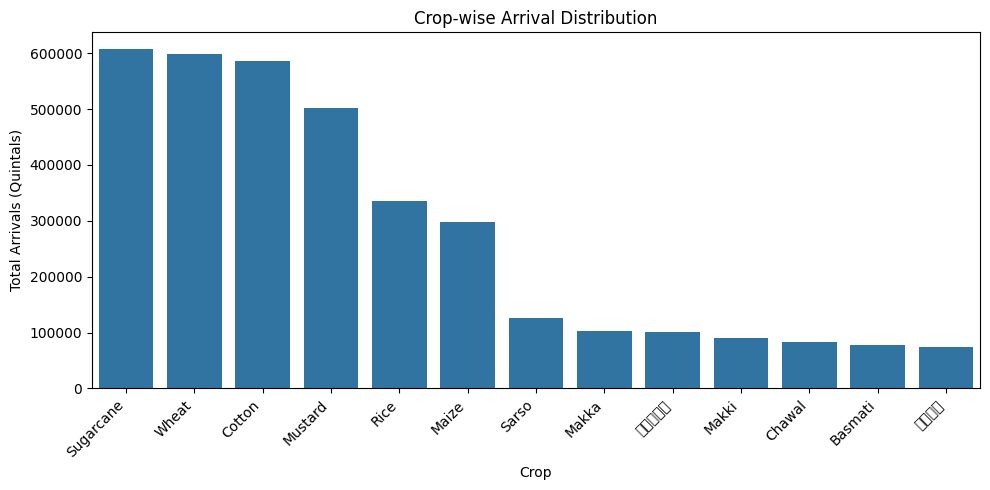

,crop_name,arrival_quantity_qtl
9,Sugarcane,607058.9938
10,Wheat,598048.3371
2,Cotton,586839.2877
6,Mustard,502780.9391
7,Rice,335107.1735
3,Maize,298117.7064
8,Sarso,126092.6216
4,Makka,103133.5328
12,मक्का,101552.3498
5,Makki,89478.9891


In [122]:
crop_arrivals = (
    arrivals_price_df.groupby('crop_name', as_index=False)
    ['arrival_quantity_qtl'].sum()
    .sort_values('arrival_quantity_qtl', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=crop_arrivals, x='crop_name', y='arrival_quantity_qtl')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop')
plt.ylabel('Total Arrivals (Quintals)')
plt.title('Crop-wise Arrival Distribution')
plt.tight_layout()
plt.show()

display(crop_arrivals)

### Insight

In [123]:
display(crop_arrivals.head(5))

,crop_name,arrival_quantity_qtl
9,Sugarcane,607058.9938
10,Wheat,598048.3371
2,Cotton,586839.2877
6,Mustard,502780.9391
7,Rice,335107.1735


The table identifies the crops contributing the highest arrival volumes.

## 22. EDA — Top Mandis

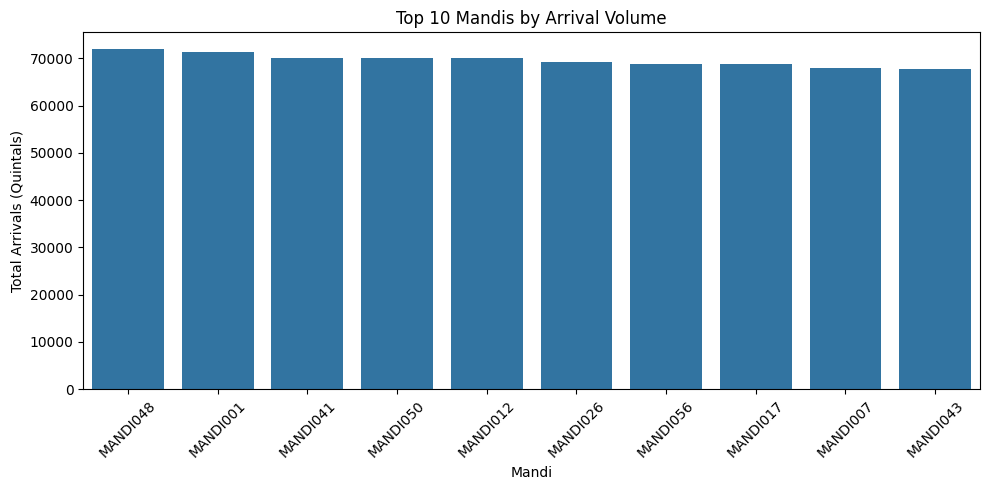

,mandi_id,mandi_name,arrival_quantity_qtl
47,MANDI048,Chittoor Mandi,71914.9943
0,MANDI001,Hyderabad Mandi,71325.0410
40,MANDI041,Gurgaon Grain Market,70136.5042
49,MANDI050,Durg Market,70118.7433
11,MANDI012,Gaya Grain Market,70110.1019
25,MANDI026,Tadipatri Mandi,69272.1708
55,MANDI056,Bilaspur Mandi,68848.2149
16,MANDI017,Parbhani Market,68732.5870
6,MANDI007,Nashik Mandi,67997.3243
42,MANDI043,Danapur Mandi,67852.5355


In [124]:
mandi_arrivals = (
    arrivals_price_df.groupby(['mandi_id','mandi_name'], as_index=False)
    ['arrival_quantity_qtl'].sum()
    .sort_values('arrival_quantity_qtl', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=mandi_arrivals.head(10),
            x='mandi_id', y='arrival_quantity_qtl')
plt.xticks(rotation=45)
plt.xlabel('Mandi')
plt.ylabel('Total Arrivals (Quintals)')
plt.title('Top 10 Mandis by Arrival Volume')
plt.tight_layout()
plt.show()

display(mandi_arrivals.head(10))

### Insight

In [125]:
display(mandi_arrivals.head(5))

,mandi_id,mandi_name,arrival_quantity_qtl
47,MANDI048,Chittoor Mandi,71914.9943
0,MANDI001,Hyderabad Mandi,71325.0410
40,MANDI041,Gurgaon Grain Market,70136.5042
49,MANDI050,Durg Market,70118.7433
11,MANDI012,Gaya Grain Market,70110.1019


This identifies the mandis handling the largest agricultural volumes.

## 23. EDA — Modal Price vs MSP

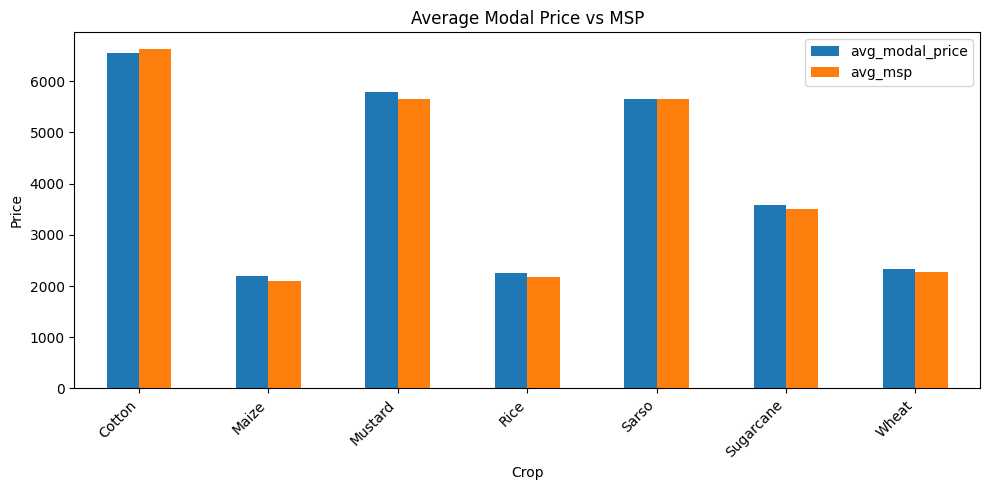

,crop_name,avg_modal_price,avg_msp
2,Cotton,6553.492680,6620.0
3,Maize,2203.700683,2090.0
6,Mustard,5780.647440,5650.0
7,Rice,2252.230000,2183.0
8,Sarso,5649.000000,5650.0
9,Sugarcane,3581.640341,3500.0
10,Wheat,2330.383676,2275.0


In [126]:
price_summary = (
    arrivals_price_df.groupby('crop_name', as_index=False)
    .agg(avg_modal_price=('modal_price','mean'),
         avg_msp=('msp','mean'))
    .dropna()
)

price_summary.plot(
    x='crop_name',
    y=['avg_modal_price','avg_msp'],
    kind='bar',
    figsize=(10,5)
)
plt.xlabel('Crop')
plt.ylabel('Price')
plt.title('Average Modal Price vs MSP')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(price_summary)

### Insight

In [127]:
price_summary['difference'] = (
    price_summary['avg_modal_price'] - price_summary['avg_msp']
)
display(price_summary.sort_values('difference'))

,crop_name,avg_modal_price,avg_msp,difference
2,Cotton,6553.492680,6620.0,-66.507320
8,Sarso,5649.000000,5650.0,-1.000000
10,Wheat,2330.383676,2275.0,55.383676
7,Rice,2252.230000,2183.0,69.230000
9,Sugarcane,3581.640341,3500.0,81.640341
3,Maize,2203.700683,2090.0,113.700683
6,Mustard,5780.647440,5650.0,130.647440


This comparison shows which crops have average modal prices above or below MSP.

## 24. EDA — Weather Impact on Arrivals

In [128]:
daily_arrivals = (
    arrivals_price_df.groupby('date', as_index=False)
    ['arrival_quantity_qtl'].sum()
)

weather_impact_df = daily_arrivals.merge(
    weather_daily_df[
        ['date','total_rainfall_mm','avg_temperature_c','avg_humidity_percent']
    ],
    on='date', how='inner'
)

corr = weather_impact_df[
    ['arrival_quantity_qtl','total_rainfall_mm']
].corr().iloc[0,1]

print("Rainfall-arrival correlation:", round(corr, 3))
display(weather_impact_df.head())

Rainfall-arrival correlation: -0.047


,date,arrival_quantity_qtl,total_rainfall_mm,avg_temperature_c,avg_humidity_percent
0,2026-01-01,1135.0200,765.932,28.841830,62.186047
1,2026-01-02,1230.1700,1154.234,29.909477,65.929825
2,2026-01-03,2501.4621,1099.740,26.112963,60.528302
3,2026-01-04,1703.6900,903.324,28.184229,65.120000
4,2026-01-05,2362.6400,964.774,28.234343,60.755102


### Insight
The rainfall-arrival correlation gives an initial relationship measure only; it does not establish causation.

In [129]:
# Start with cleaned arrivals
final_df = arrivals_df.copy()
# Ensure 'date' column in final_df is datetime64[ns] for consistent merging
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')

# --------------------------------------------------
# 1. JOIN MANDI MASTER
# --------------------------------------------------

master_cols = [
    col for col in [
        "mandi_id",
        "mandi_name",
        "district",
        "mandi_type"
    ]
    if col in mandi_master_df.columns
]

final_df = final_df.merge(
    mandi_master_df[master_cols].drop_duplicates("mandi_id"),
    on="mandi_id",
    how="left"
)

print("After Mandi Master join:", final_df.shape)


# --------------------------------------------------
# 2. JOIN PRICE + MSP
# --------------------------------------------------

# Ensure price_msp_df['date'] is also datetime64[ns] for merging
price_msp_df['date'] = pd.to_datetime(price_msp_df['date'], errors='coerce')

price_keys = [
    col for col in [
        "mandi_id",
        "date",
        "crop_name"
    ]
    if col in final_df.columns and col in price_msp_df.columns
]

price_cols = price_keys + [
    col for col in [
        "modal_price",
        "msp"
    ]
    if col in price_msp_df.columns
]

price_join = price_msp_df[price_cols].drop_duplicates(price_keys);

final_df = final_df.merge(
    price_join,
    on=price_keys,
    how="left"
)

print("After Price/MSP join:", final_df.shape)


# --------------------------------------------------
# 3. JOIN DAILY WEATHER
# --------------------------------------------------

# Use the already aggregated weather_daily_df
weather_daily_for_merge = weather_daily_df[
    ['date', 'avg_temperature_c', 'total_rainfall_mm', 'avg_humidity_percent']
].copy()


final_df = final_df.merge(
    weather_daily_for_merge,
    on="date",
    how="left"
)

print("After Weather join:", final_df.shape)


# --------------------------------------------------
# 4. AGGREGATE TRANSPORT
# --------------------------------------------------

# Prepare transport_logistics_df with derived columns first
transport_temp_df = transport_logistics_df.copy()

# Calculate avg_speed_kmph
if 'avg_speed_kmph' not in transport_temp_df.columns:
    transport_temp_df['avg_speed_kmph'] = np.where(
        transport_temp_df['transit_hours_clean'] != 0,
        transport_temp_df['distance_km'] / transport_temp_df['transit_hours_clean'],
        np.nan
    )

# Calculate long_transit_flag (for transit_delay_rate)
if 'long_transit_flag' not in transport_temp_df.columns:
    transport_temp_df['long_transit_flag'] = (transport_temp_df['transit_hours_clean'] > 24).astype(float)


transport_summary = transport_temp_df.groupby(
    "mandi_id"
).agg(
    avg_distance_km=("distance_km", "mean"),
    avg_transit_hours=("transit_hours_clean", "mean"),
    avg_speed_kmph=("avg_speed_kmph", "mean"),
    transit_delay_rate=("long_transit_flag", "mean")
).reset_index()

final_df = final_df.merge(
    transport_summary,
    on="mandi_id",
    how="left"
)

print("After Transport join:", final_df.shape)


# --------------------------------------------------
# FINAL DATASET
# --------------------------------------------------

print("\nFinal integrated dataset:")
print(final_df.shape)

display(final_df.head())

After Mandi Master join: (25000, 12)
After Price/MSP join: (25000, 14)
After Weather join: (25000, 17)
After Transport join: (25000, 21)

Final integrated dataset:
(25000, 21)


,arrival_id,date,mandi_id,crop_name,variety,arrival_quantity,unit,farmer_count,arrival_quantity_qtl,mandi_name,...,mandi_type,modal_price,msp,avg_temperature_c,total_rainfall_mm,avg_humidity_percent,avg_distance_km,avg_transit_hours,avg_speed_kmph,transit_delay_rate
0,ARR0012424,2026-04-06,MANDI026,Wheat,Hybrid,44.841,T,128.0,448.4100,Tadipatri Mandi,...,Private,NaN,NaN,26.485317,720.034,68.714286,626.865517,12.396301,62.665846,0.011976
1,ARR0008271,NaT,MANDI014,Wheat,HD-2967,332.54,Qtl,33.0,332.5400,Bathinda Grain Market,...,PRIVATE,NaN,NaN,NaN,NaN,NaN,666.869466,13.377100,107.368965,0.042424
2,ARR0022724,NaT,MANDI056,Wheat,HD-2967,415.88 qtl,NaN,NaN,NaN,Bilaspur Mandi,...,Private,NaN,NaN,NaN,NaN,NaN,647.007732,13.439360,82.796480,0.056995
3,ARR0012573,NaT,MANDI019,Maize,NaN,-107.13,KG,112.0,-1.0713,Karimnagar Grain Market,...,PRIVATE,NaN,NaN,NaN,NaN,NaN,637.518379,13.427884,49.666285,0.051429
4,ARR0012098,NaT,MANDI050,Maize,Premium,-331.59,Qtl,NaN,-331.5900,Durg Market,...,NaN,NaN,NaN,NaN,NaN,NaN,669.499160,13.950960,51.542828,0.064516


Exporting the Final Dataset


In [130]:
final_df.to_csv('final_integrated_dataset.csv', index=False)
print("Final integrated dataset exported to 'final_integrated_dataset.csv'")

Final integrated dataset exported to 'final_integrated_dataset.csv'


## 25. Dashboard KPI Table

In [131]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Crop Arrivals (Qtl)',
        'Average Modal Price',
        'Average MSP',
        'Price Crash Instances',
        'Average Transit Time (Hours)',
        'Transit Delay Rate (%)'
    ],
    'Value': [
        arrivals_price_df['arrival_quantity_qtl'].sum(),
        arrivals_price_df['modal_price'].mean(),
        arrivals_price_df['msp'].mean(),
        arrivals_price_df['price_crash'].sum(),
        transport_logistics_df['transit_hours_clean'].mean(),
        transport_logistics_df['long_transit_flag'].mean() * 100
    ]
})

kpi_summary['Value'] = kpi_summary['Value'].round(2)
display(kpi_summary)

,Metric,Value
0,Total Crop Arrivals (Qtl),3582896.96
1,Average Modal Price,4075.52
2,Average MSP,4030.65
3,Price Crash Instances,29.00
4,Average Transit Time (Hours),13.53
5,Transit Delay Rate (%),4.28


### Insight
This table is the summary KPI layer for the Power BI dashboard.

## 26. Final Data Quality Check

In [132]:
final_quality = pd.DataFrame({
    'Check': [
        'Negative arrival quantities',
        'Negative distances',
        'Negative cleaned transit',
        'Missing arrival dates',
        'Missing modal prices',
        'Missing weather timestamps',
        'Missing vehicle numbers'
    ],
    'Count': [
        (arrivals_price_df['arrival_quantity_qtl'] < 0).sum(),
        (transport_enriched_df['distance_km'] < 0).sum(),
        (transport_enriched_df['transit_hours_clean'] < 0).sum(),
        arrivals_price_df['date'].isna().sum(),
        arrivals_price_df['modal_price'].isna().sum(),
        weather_sensors_df['timestamp_ist'].isna().sum(),
        transport_enriched_df['vehicle_no_clean'].isna().sum()
    ]
})

display(final_quality)

,Check,Count
0,Negative arrival quantities,1234
1,Negative distances,0
2,Negative cleaned transit,0
3,Missing arrival dates,23456
4,Missing modal prices,24910
5,Missing weather timestamps,1985
6,Missing vehicle numbers,1560


### Final Insight
The final check reports remaining data-quality issues explicitly and confirms that cleaned quantities, distances and transit times do not retain negative values.

## 27. Dashboard Structure

- **Overview:** total arrivals, modal price, MSP, price-crash count
- **Mandi Analysis:** top mandis and district/state distribution
- **Crop & Price:** crop arrivals, modal price vs MSP, price spread
- **Transport:** transit time, distance, warehouse analysis, long-transit rate
- **Weather Impact:** rainfall, temperature and arrival trends